In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [5]:
r_table.head()

,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,exp,nn,1sig,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir
0,1,0,0,0,159.0,145.788047,148.685925,2.897877,2.897877,145.788047,145.788047,1.0,1.0,1.0,divided,high,expected,132,373,higher
1,1,0,0,1,123.0,136.060195,129.253756,6.806439,-6.806439,145.788047,136.060195,1.0,1.0,1.0,focused,high,unexpected,204,280,lower
2,1,0,0,2,51.0,33.954344,124.965094,91.010750,91.010750,145.788047,136.060195,0.0,0.0,0.0,focused,high,unexpected,168,250,higher
3,1,0,0,3,159.0,145.788047,145.702460,0.085587,-0.085587,145.788047,145.788047,1.0,1.0,1.0,divided,high,expected,168,337,lower
4,1,0,0,4,15.0,18.896223,144.334808,125.438585,125.438585,145.788047,145.788047,0.0,0.0,0.0,divided,low,unexpected,180,270,higher


### Targets

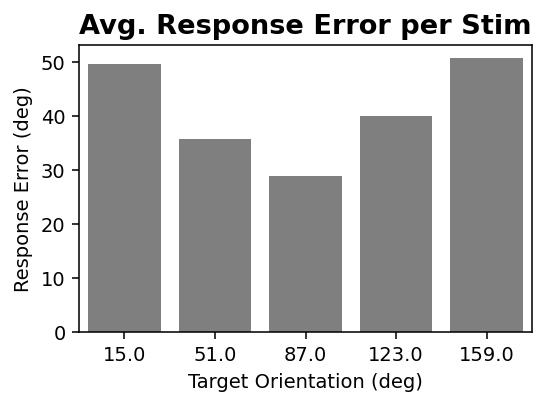

In [15]:
plt.figure(figsize=(4, 3))
sns.barplot(r_table.groupby("target").resp_err.mean(), color='black', alpha=0.5)
plt.ylabel("Response Error (deg)")
plt.xlabel("Target Orientation (deg)")
plt.title("Avg. Response Error per Stim", fontsize=14, weight='bold')
plt.tight_layout()

### reaction times

In [3]:
rt = (r_table.f_resp.values - 250).reshape(12, 4, 6, 120)*(1000/120)

In [4]:
berrs = r_table.resp_err.values.reshape(12, 4, 6, 120)
s_errs = berrs.reshape(12, -1).mean(axis=1)
s_idx = np.argsort(s_errs)

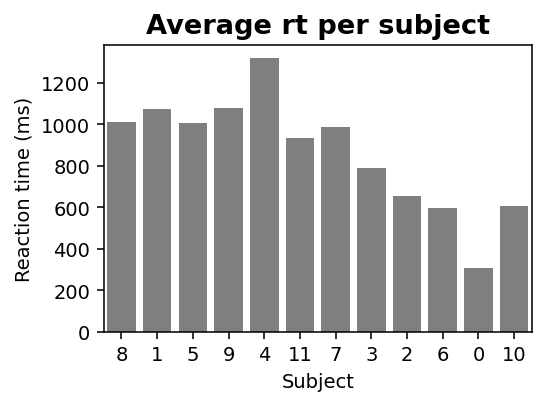

In [5]:
# Aveg subject errors
s_rt = rt.reshape(12, -1).mean(axis=1)
plt.figure(figsize=(4, 3))
sns.barplot(x=range(12), y=s_rt[s_idx], color='black', alpha=0.5)
plt.xticks(range(12), s_idx)
plt.xlabel('Subject')
plt.ylabel('Reaction time (ms)')
plt.title('Average rt per subject', fontsize=14, fontweight='bold')
plt.tight_layout()

Text(0.5, 1.0, 'rt of fav. subject')

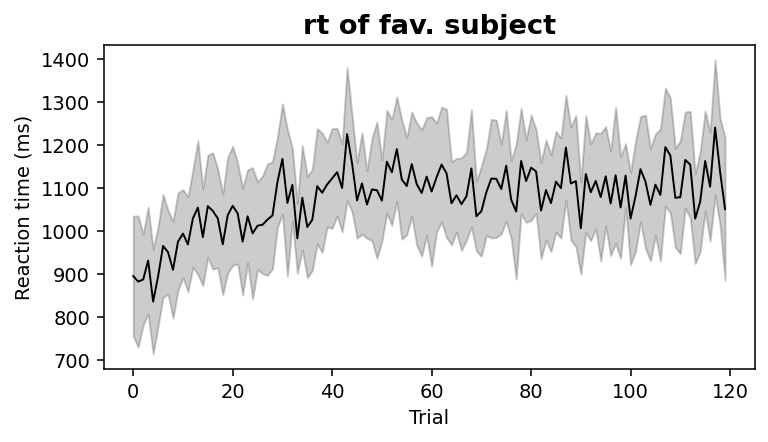

In [6]:
fav = 1
plt.figure(figsize=(6, 3))
plt.plot(rt[fav].reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
# also plot the sem
sem = rt[fav].reshape(-1, 120).std(axis=0) / np.sqrt(rt[fav].shape[0])
plt.fill_between(np.arange(120), 
                 rt[fav].reshape(-1, 120).mean(axis=0) - sem,
                 rt[fav].reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
plt.xlabel('Trial')
plt.ylabel('Reaction time (ms)')
plt.title('rt of fav. subject', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Average rt across subjects')

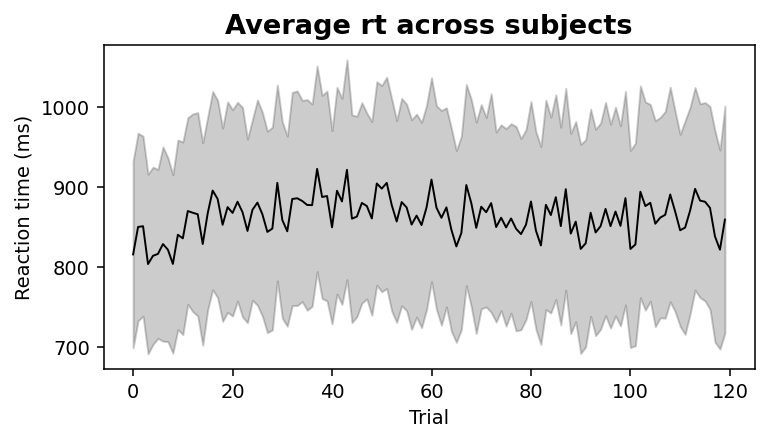

In [7]:
plt.figure(figsize=(6, 3))
plt.plot(rt.reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
# also plot the sem
sem = rt.reshape(-1, 120).std(axis=0) / np.sqrt(rt.shape[0])
plt.fill_between(np.arange(120), 
                 rt.reshape(-1, 120).mean(axis=0) - sem,
                 rt.reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
plt.xlabel('Trial')
plt.ylabel('Reaction time (ms)')
plt.title('Average rt across subjects', fontsize=14, fontweight='bold')

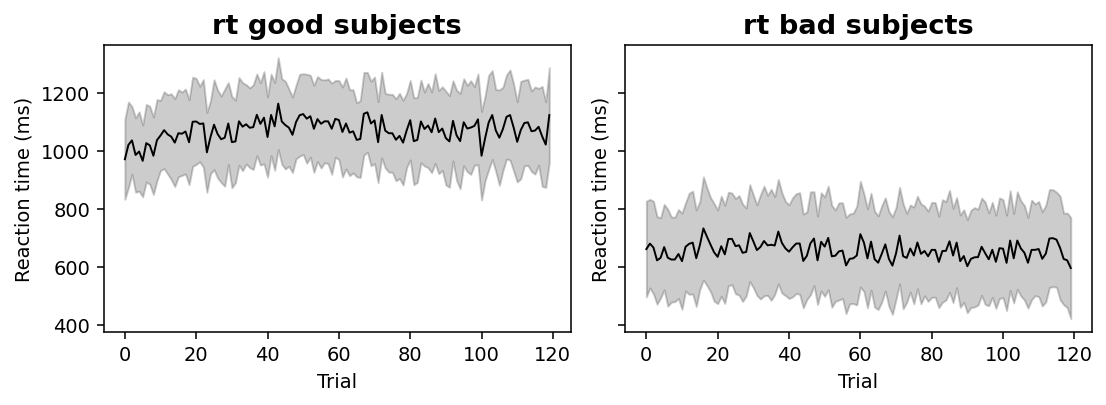

In [8]:
good_subs = s_idx[:6]
bad_subs = s_idx[6:]
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
ax[0].plot(rt[good_subs].reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
sem = rt[good_subs].reshape(-1, 120).std(axis=0) / np.sqrt(rt[good_subs].shape[0])
ax[0].fill_between(np.arange(120), 
                 rt[good_subs].reshape(-1, 120).mean(axis=0) - sem,
                 rt[good_subs].reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
ax[0].set_xlabel('Trial')
ax[0].set_ylabel('Reaction time (ms)')
ax[0].set_title('rt good subjects', fontsize=14, fontweight='bold')

ax[1].plot(rt[bad_subs].reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
sem = rt[bad_subs].reshape(-1, 120).std(axis=0) / np.sqrt(rt[bad_subs].shape[0])
ax[1].fill_between(np.arange(120), 
                 rt[bad_subs].reshape(-1, 120).mean(axis=0) - sem,
                 rt[bad_subs].reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
ax[1].set_xlabel('Trial')
ax[1].set_ylabel('Reaction time (ms)')
ax[1].set_title('rt bad subjects', fontsize=14, fontweight='bold')
plt.tight_layout()

Text(0.5, 1.0, 'Average rt per session')

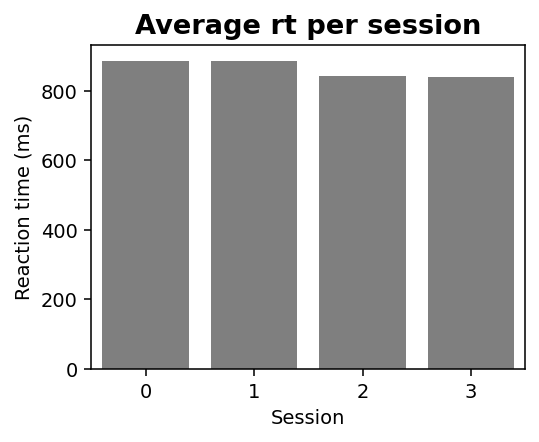

In [9]:
# Average rt by session
plt.figure(figsize=(4, 3))

sess_errs = rt.transpose(1, 0, 2, 3).reshape(4, -1).mean(axis=1)
sns.barplot(x=range(4), y=sess_errs, color='black', alpha=0.5)
plt.xlabel('Session')
plt.ylabel('Reaction time (ms)')
plt.title('Average rt per session', fontsize=14, fontweight='bold')

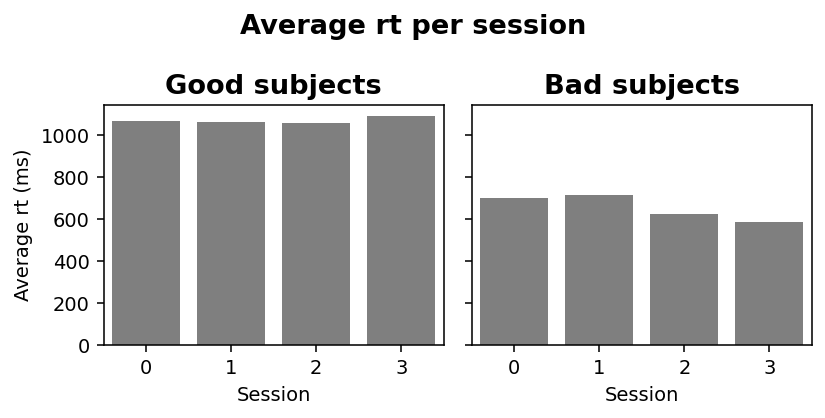

In [21]:
# rt by session divided to good and bad subjects
good_subs = s_idx[:6]
bad_subs = s_idx[6:]
fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
good_errs = rt[good_subs].transpose(1, 0, 2, 3).reshape(4, -1).mean(axis=1)
sns.barplot(x=range(4), y=good_errs, color='black', alpha=0.5, ax=ax[0])
ax[0].set_xlabel('Session')
ax[0].set_ylabel('Average rt (ms)')
ax[0].set_title('Good subjects', fontsize=14, fontweight='bold')
bad_errs = rt[bad_subs].transpose(1, 0, 2, 3).reshape(4, -1).mean(axis=1)
sns.barplot(x=range(4), y=bad_errs, color='black', alpha=0.5, ax=ax[1])
ax[1].set_xlabel('Session')
ax[1].set_ylabel('Average rt (ms)')
ax[1].set_title('Bad subjects', fontsize=14, fontweight='bold')
plt.suptitle('Average rt per session', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Average rt per run')

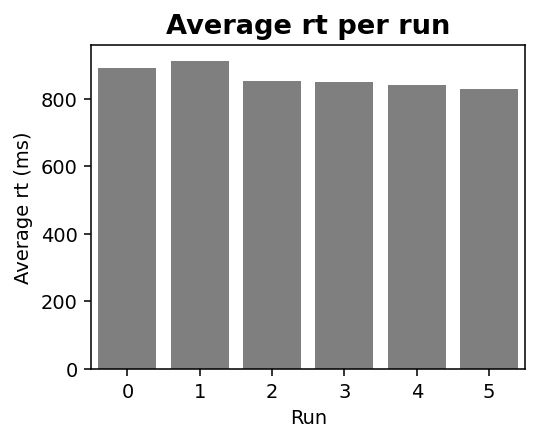

In [11]:
# Average rt by runs
plt.figure(figsize=(4, 3))
runs_errs = rt.transpose(1, 2, 0, 3).reshape(6, -1).mean(axis=1)
sns.barplot(x=range(6), y=runs_errs, color='black', alpha=0.5)
plt.xlabel('Run')
plt.ylabel('Average rt (ms)')
plt.title('Average rt per run', fontsize=14, fontweight='bold')

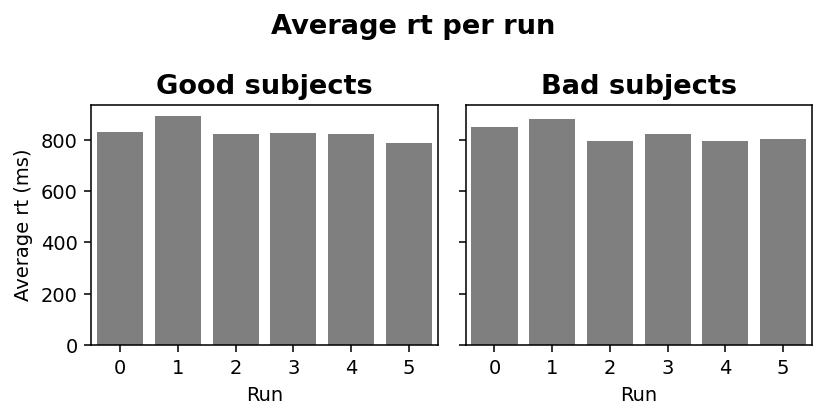

In [22]:
# same average rt by runs but good subjects and bad subjects
fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
good_errs = rt.transpose(1, 2, 0, 3)[..., good_subs].reshape(6, -1).mean(axis=1)
sns.barplot(x=range(6), y=good_errs, color='black', alpha=0.5, ax=ax[0])
ax[0].set_xlabel('Run')
ax[0].set_ylabel('Average rt (ms)')
ax[0].set_title('Good subjects', fontsize=14, fontweight='bold')
bad_errs = rt.transpose(1, 2, 0, 3)[..., bad_subs].reshape(6, -1).mean(axis=1)
sns.barplot(x=range(6), y=bad_errs, color='black', alpha=0.5, ax=ax[1])
ax[1].set_xlabel('Run')
ax[1].set_ylabel('Average rt (ms)')
ax[1].set_title('Bad subjects', fontsize=14, fontweight='bold')
plt.suptitle('Average rt per run', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Errs

In [13]:
berrs = r_table.resp_err.values.reshape(12, 4, 6, 120)
s_errs = berrs.reshape(12, -1).mean(axis=1)
s_idx = np.argsort(s_errs)

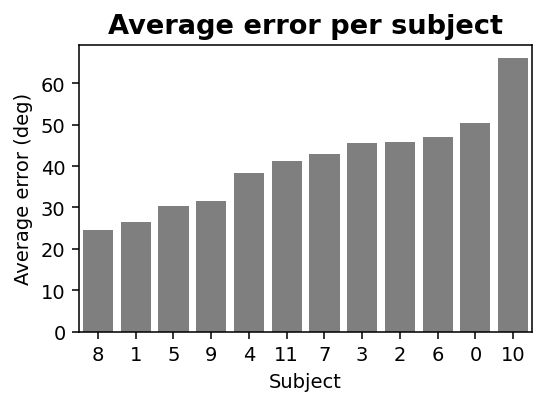

In [14]:
plt.figure(figsize=(4, 3))
sns.barplot(x=range(12), y=s_errs[s_idx], color='black', alpha=0.5)
plt.xticks(range(12), s_idx)
plt.xlabel('Subject')
plt.ylabel('Average error (deg)')
plt.title('Average error per subject', fontsize=14, fontweight='bold')
plt.tight_layout()

Text(0.5, 1.0, 'Average Response Error in a block')

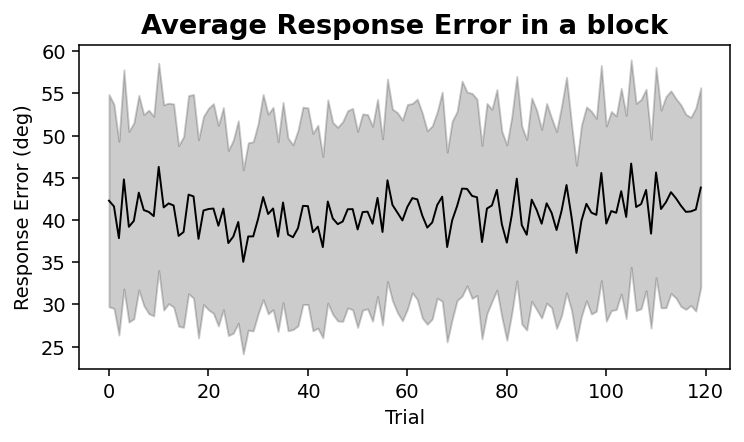

In [15]:
plt.figure(figsize=(6, 3))
plt.plot(berrs.reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
# also plot the sem
sem = berrs.reshape(-1, 120).std(axis=0) / np.sqrt(berrs.shape[0])
plt.fill_between(np.arange(120), 
                 berrs.reshape(-1, 120).mean(axis=0) - sem,
                 berrs.reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
plt.xlabel('Trial')
plt.ylabel('Response Error (deg)')
plt.title('Average Response Error in a block', fontsize=14, fontweight='bold')

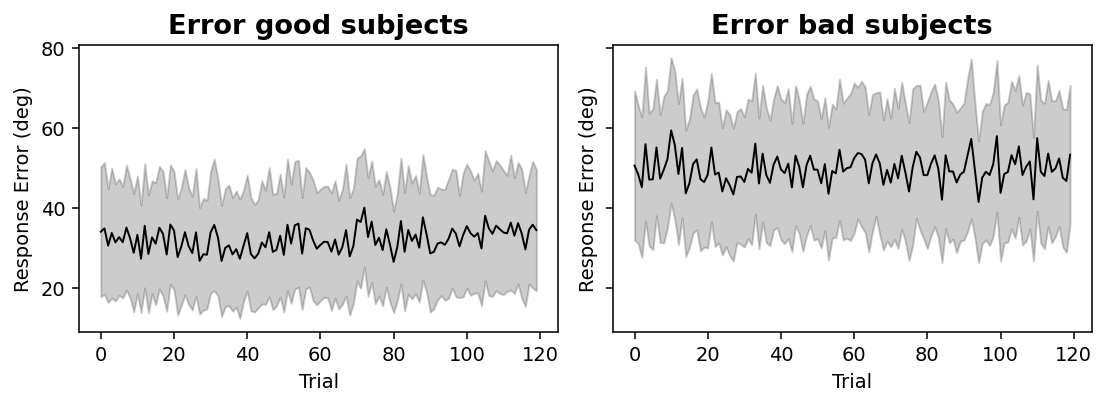

In [16]:
good_subs = s_idx[:6]
bad_subs = s_idx[6:]
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
ax[0].plot(berrs[good_subs].reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
sem = berrs[good_subs].reshape(-1, 120).std(axis=0) / np.sqrt(berrs[good_subs].shape[0])
ax[0].fill_between(np.arange(120), 
                 berrs[good_subs].reshape(-1, 120).mean(axis=0) - sem,
                 berrs[good_subs].reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
ax[0].set_xlabel('Trial')
ax[0].set_ylabel('Response Error (deg)')
ax[0].set_title('Error good subjects', fontsize=14, fontweight='bold')

ax[1].plot(berrs[bad_subs].reshape(-1, 120).mean(axis=0), color='black', linewidth=1)
sem = berrs[bad_subs].reshape(-1, 120).std(axis=0) / np.sqrt(berrs[bad_subs].shape[0])
ax[1].fill_between(np.arange(120), 
                 berrs[bad_subs].reshape(-1, 120).mean(axis=0) - sem,
                 berrs[bad_subs].reshape(-1, 120).mean(axis=0) + sem,
                 alpha=0.2, color='black')
ax[1].set_xlabel('Trial')
ax[1].set_ylabel('Response Error (deg)')
ax[1].set_title('Error bad subjects', fontsize=14, fontweight='bold')
plt.tight_layout()

Text(0.5, 1.0, 'Average error per session')

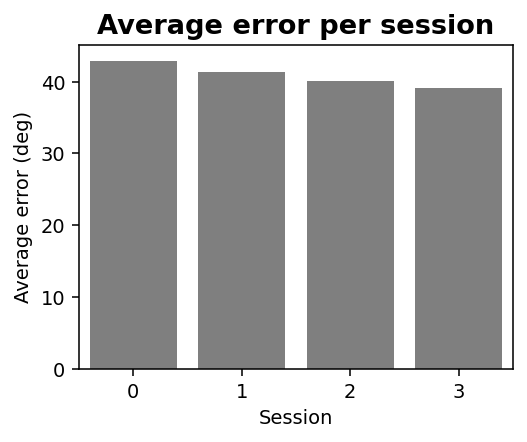

In [17]:
# Average error by session
plt.figure(figsize=(4, 3))

sess_errs = berrs.transpose(1, 0, 2, 3).reshape(4, -1).mean(axis=1)
sns.barplot(x=range(4), y=sess_errs, color='black', alpha=0.5)
plt.xlabel('Session')
plt.ylabel('Average error (deg)')
plt.title('Average error per session', fontsize=14, fontweight='bold')

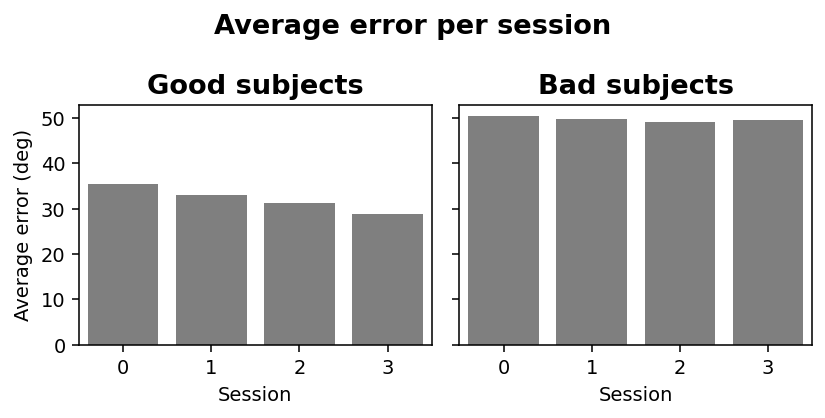

In [23]:
# same average error by session but good subjects and bad subjects
good_subs = s_idx[:6]
bad_subs = s_idx[6:]
fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
good_errs = berrs[good_subs].transpose(1, 0, 2, 3).reshape(4, -1).mean(axis=1)
sns.barplot(x=range(4), y=good_errs, color='black', alpha=0.5, ax=ax[0])
ax[0].set_xlabel('Session')
ax[0].set_ylabel('Average error (deg)')
ax[0].set_title('Good subjects', fontsize=14, fontweight='bold')
bad_errs = berrs[bad_subs].transpose(1, 0, 2, 3).reshape(4, -1).mean(axis=1)
sns.barplot(x=range(4), y=bad_errs, color='black', alpha=0.5, ax=ax[1])
ax[1].set_xlabel('Session')
ax[1].set_ylabel('Average error (deg)')
ax[1].set_title('Bad subjects', fontsize=14, fontweight='bold')
plt.suptitle('Average error per session', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Average error per run')

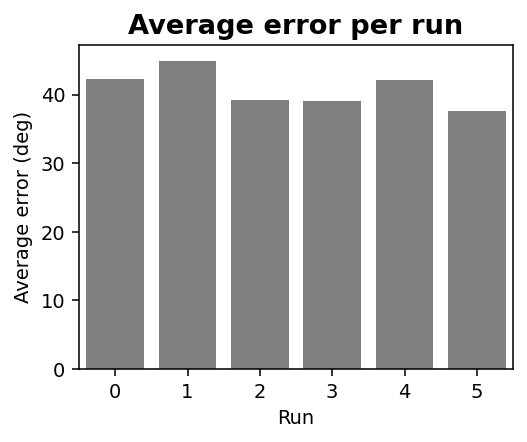

In [19]:
# Average error by runs
plt.figure(figsize=(4, 3))
runs_errs = berrs.transpose(1, 2, 0, 3).reshape(6, -1).mean(axis=1)
sns.barplot(x=range(6), y=runs_errs, color='black', alpha=0.5)
plt.xlabel('Run')
plt.ylabel('Average error (deg)')
plt.title('Average error per run', fontsize=14, fontweight='bold')

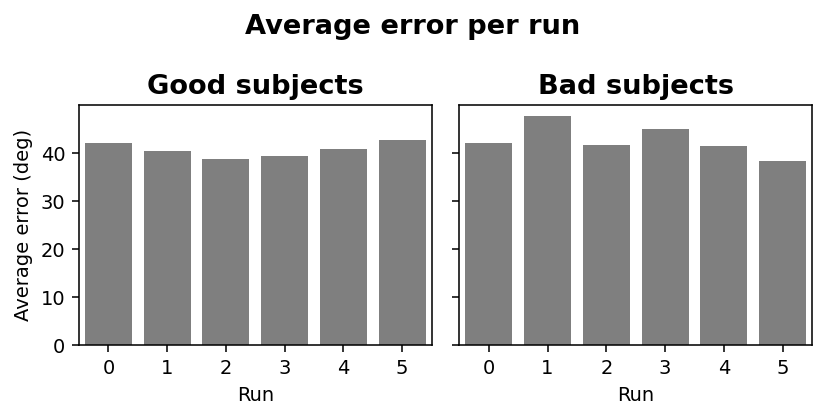

In [24]:
# same average error by runs but good subjects and bad subjects
fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
good_errs = berrs.transpose(1, 2, 0, 3)[..., good_subs].reshape(6, -1).mean(axis=1)
sns.barplot(x=range(6), y=good_errs, color='black', alpha=0.5, ax=ax[0])
ax[0].set_xlabel('Run')
ax[0].set_ylabel('Average error (deg)')
ax[0].set_title('Good subjects', fontsize=14, fontweight='bold')
bad_errs = berrs.transpose(1, 2, 0, 3)[..., bad_subs].reshape(6, -1).mean(axis=1)
sns.barplot(x=range(6), y=bad_errs, color='black', alpha=0.5, ax=ax[1])
ax[1].set_xlabel('Run')
ax[1].set_ylabel('Average error (deg)')
ax[1].set_title('Bad subjects', fontsize=14, fontweight='bold')
plt.suptitle('Average error per run', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()